# SAM RTN Quantization Analysis

This notebook provides a comprehensive analysis of RTN (Round-to-Nearest) quantization for SAM models, focusing on MSE measurement across attention layers.


In [1]:
from observers import (
    image_encoder_observer_patch, 
    ImageEncoderViTObserver,

) 
from segment_anything.modeling.image_encoder import (
    window_partition,
    window_unpartition,
)
from utils import inference_image
from segment_anything import SamPredictor, sam_model_registry
import torch
import torch.nn.functional as F
import matplotlib.pyplot  as plt


/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwri

In [2]:
model_type = 'vit_l'
checkpoint_path= './pretrained_checkpoint/sam_hq_vit_l.pth'
sam = sam_model_registry[model_type](checkpoint=checkpoint_path).to('cuda')
predictor = SamPredictor(sam)
image_encoder_observer_patch(predictor.model)

<All keys matched successfully>


(1000, 894, 3)


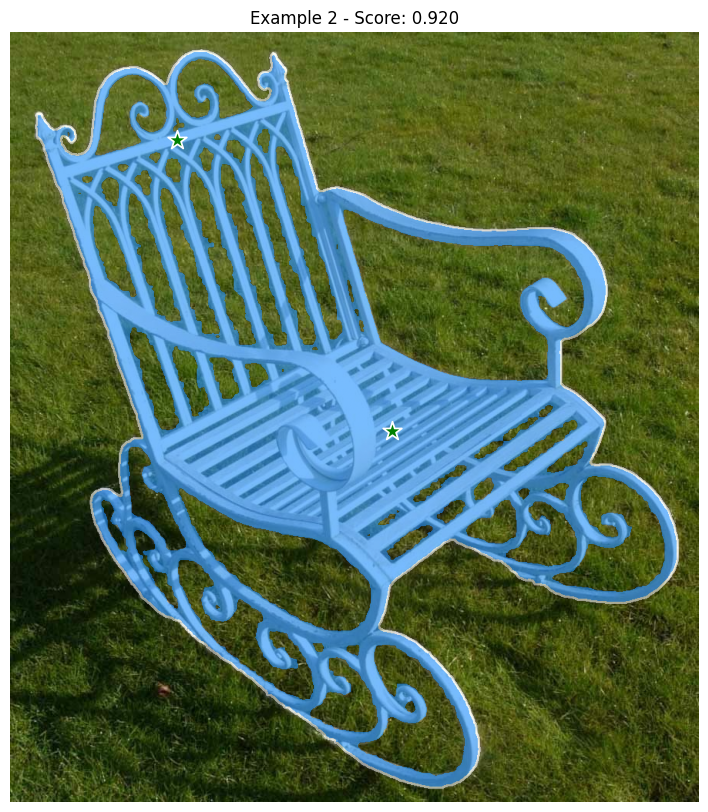

(array([[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],
       shape=(1, 1000, 894)),
 array([0.91993], dtype=float32),
 array([[[ -9.819817 , -12.19165  , -10.208868 , ...,  -8.438784 ,
           -9.517096 ,  -9.359494 ],
         [-10.38857  , -13.301583 ,  -9.985376 , ...,  -9.34211  ,
          -10.048056 , -10.236759 ],
         [-10.228151 , -12.927952 , -10.906278 , ...,  -9.326048 ,
          -11.062877 , -10.994862 ],
         ...,
         [ -7.5699973, -11.632122 , -10.298674 , ...,  -5.1798606,
           -7.000796 ,  -6.512075 ],
         [ -9.654377 , -11.936314 , -11.072433 , ...,  -7.0241604,
           -8.113507 ,  -7.5489454],
         [-10.051227 , -11.582567 , -1

In [3]:
inference_image(predictor, image_dir='./input_imgs/', example_idx=2, show_image=True)

In [4]:
ImageEncoderViTObserver.attention_score.keys()

dict_keys(['block_x', 'block_x_hat', 'block_x_mean', 'block_q', 'block_k', 'block_v', 'block_q_hat', 'block_k_hat', 'block_v_hat', 'block_x_attn', 'block_attn', 'block_attn_mean', 'block_attn_ori', 'block_q_mean', 'block_v_mean'])

In [5]:

def get_attention_map_hat(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_attn'][layer_idx]
    return attn

def get_attention_map_mean(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_attn_mean'][layer_idx]
    return attn


def get_attention_map_ori(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_attn_ori'][layer_idx]
    return attn


def get_feature(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_x'][layer_idx]
    return x

def get_feature_mean(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_x_mean'][layer_idx]
    print('x_mean', x.shape)
    return x

def get_feature_hat(layer_idx:int):
    x_hat = ImageEncoderViTObserver.attention_score[f'block_x_hat'][layer_idx]
    print('x_hat', x_hat.shape)
    return x_hat

def get_feature_hat(layer_idx:int):
    x_hat = ImageEncoderViTObserver.attention_score[f'block_x_mean'][layer_idx]
    return x_hat

def get_feature_attn(layer_idx:int):
    x_hat = ImageEncoderViTObserver.attention_score[f'block_x_attn'][layer_idx]
    return x_hat

def get_q(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_q_hat'][layer_idx]
    return x
def get_k(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_k_hat'][layer_idx]
    return x
def get_v(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_v_hat'][layer_idx]
    return x

def get_q_mean(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_q_mean'][layer_idx]
    return x
def get_v_mean(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_v_mean'][layer_idx]
    return x

def get_q(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_q_hat'][layer_idx]
    return x
def get_k(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_k_hat'][layer_idx]
    return x
def get_v(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_v_hat'][layer_idx]
    return x

def get_q_mean(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_q_mean'][layer_idx]
    return x
def get_v_mean(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_v_mean'][layer_idx]
    return x


def cal_energy(X:torch.Tensor, margin=0.9):
    """
    Calculate the energy of the input tensor.
    """
    X = F.normalize(X, dim=-1, p=2)
    score_map = F.elu(X @ X.transpose(-1, -2) - margin)
    scores = score_map.mean(-1)
    return scores

def recal_attn(q, k, v):
    attn = (q * 1/8) @ k.transpose(-2, -1)
    attn = attn.softmax(dim=-1)
    return attn



In [6]:
from matplotlib import pyplot as plt 
import torch
layer_idx = 15 
q = torch.from_numpy(get_q(layer_idx))
k = torch.from_numpy(get_k(layer_idx)) 
v = torch.from_numpy(get_v(layer_idx)) 
x = torch.from_numpy(get_feature(layer_idx))
x_attn = torch.from_numpy(get_feature_attn(layer_idx))
x_hat = torch.from_numpy(ImageEncoderViTObserver.attention_score[f'block_x_hat'][layer_idx])

In [7]:
x.shape

torch.Size([25, 196, 1024])

In [8]:
energy = cal_energy(x, margin=0.9)
if energy.shape[0] > 1: 
    energy_unpartitioned = window_unpartition(energy, 14, (70,70), (64,64))

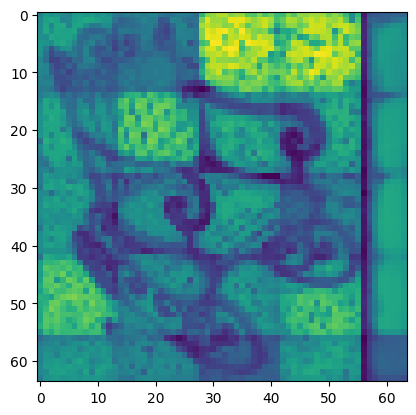

In [9]:
plt.imshow(energy_unpartitioned.reshape(64,64))

In [10]:

head_idx = 0
layer_idx = 17 
# q = get_q(layer_idx)[head_idx]
# k = get_k(layer_idx)[head_idx]
# v = get_k(layer_idx)[head_idx]
attn = get_attention_map_hat(layer_idx)
attn_mean = get_attention_map_mean(layer_idx)
attn_ori= get_attention_map_ori(layer_idx)


# plt.imshow(ori_attn.mean(-1).reshape(64,64))

def show_attn_map(attn_map):
    fig, axes = plt.subplots(2,8,figsize=(30,8))
    for i in range(8):
        axes[0][i].imshow(attn_map[2*i].mean(0).reshape(64,64))
        axes[1][i].imshow(attn_map[2*i+1].mean(0).reshape(64,64))


print(attn_ori.shape)
# show_attn_map(attn_ori)



(16, 4096, 4096)


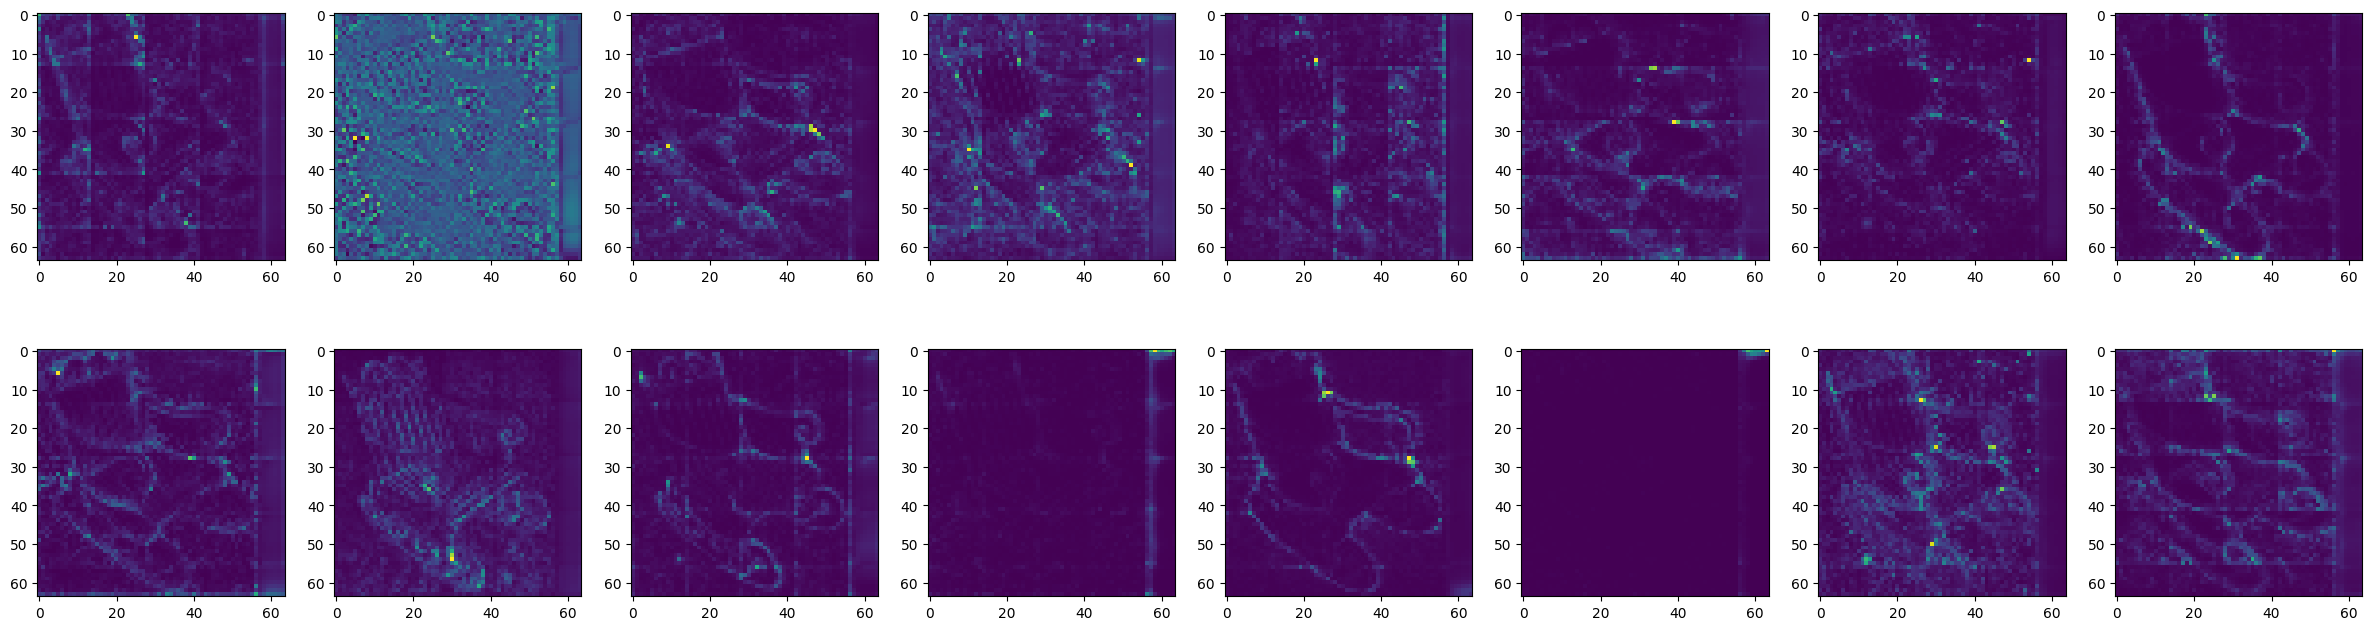

In [11]:
show_attn_map(attn)

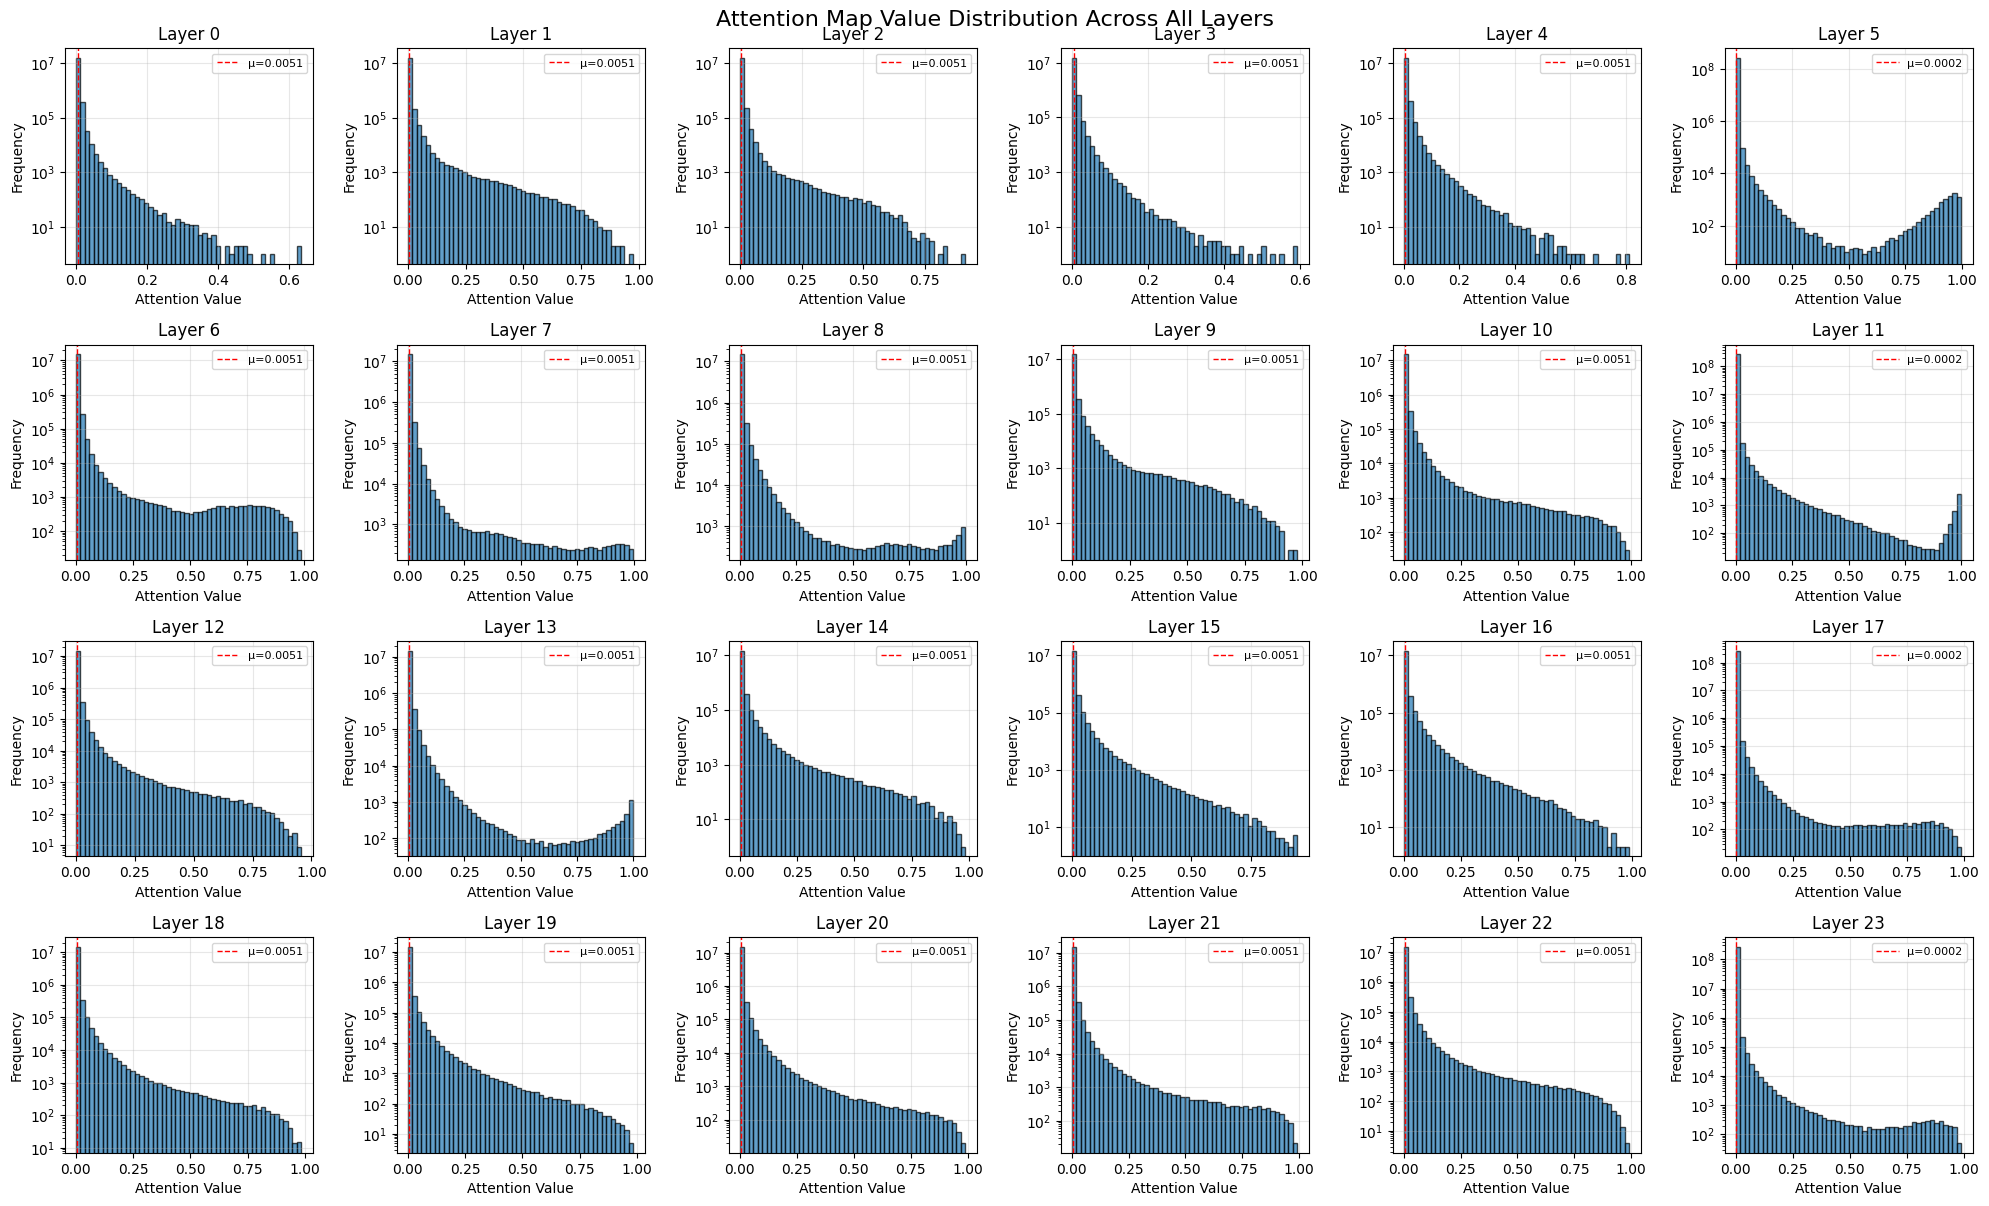

In [12]:
# Plot distribution of attention map values across different layers
import numpy as np

fig, axes = plt.subplots(4, 6, figsize=(20, 12))
axes = axes.flatten()

for layer_idx in range(24):
    attn = get_attention_map_hat(layer_idx)
    attn_flat = attn.flatten()
    
    axes[layer_idx].hist(attn_flat, bins=50, alpha=0.7, edgecolor='black',  log=True)
    axes[layer_idx].set_title(f'Layer {layer_idx}')
    axes[layer_idx].set_xlabel('Attention Value')
    axes[layer_idx].set_ylabel('Frequency')
    axes[layer_idx].grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = np.mean(attn_flat)
    std_val = np.std(attn_flat)
    axes[layer_idx].axvline(mean_val, color='r', linestyle='--', linewidth=1, label=f'μ={mean_val:.4f}')
    axes[layer_idx].legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Attention Map Value Distribution Across All Layers', y=1.001, fontsize=16)
plt.show()

In [ ]:
# get_activation_boxplot(
#     high_activations=q.reshape(-1,q.shape[-1]), 
#     low_activations=(k.reshape(-1,k.shape[-1])), 
#     ax=ax, 
#     offset=0, 
#     max_channels=32,
#     token_wise=False
# )